[Spreadsheet](https://docs.google.com/spreadsheets/d/1Wi0xMvsG87rtHuU238yYiYHKfPE6V9gCyebaufrZVFc/edit?usp=sharing)

https://www.learnpytorch.io/

## **Todos**

* Speed things up

# PyTorch Transfer Learning

**Transfer learning** allows us to take the patterns (also called weights) another model has learned from another problem and use them for our own problem.

---

Why use transfer learning?

There are two main benefits to using transfer learning:

* Can leverage an existing model (usually a neural network architecture) proven to work on problems similar to our own.

* Can leverage a working model which has already learned patterns on similar data to our own. This often results in achieving great results with less custom data.

---

Machine learning research paper recommended practitioners **use transfer learning wherever possible**


https://www.learnpytorch.io/06_pytorch_transfer_learning/

Using **Automatic Mixed Precision** (AMP) in PyTorch (or TensorFlow) does not fundamentally change the behavior of your model, but it can introduce small numerical differences.

## **0. Imports | Device Agnostic | Constants**

In [ ]:
%%capture
!pip install torchdistill

In [ ]:
import os
import time
import random
import requests
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Extract tar files
import tarfile

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms as T, models as M
from torch.amp import autocast_mode, autocast, GradScaler

torch.__version__, torchvision.__version__

('2.8.0+cu126', '0.23.0+cu126')

Experiment Tracking

In [ ]:
try:
    from torch.utils.tensorboard import SummaryWriter
except:
    print("[INFO] Couldn't find tensorboard... installing it.")
    !pip install -q tensorboard
    from torch.utils.tensorboard import SummaryWriter

In [ ]:
if torch.cuda.is_available():
  !nvidia-smi

Sat Aug 30 20:41:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
DEVICE = "mps" if torch.mps.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else DEVICE
DEVICE

'cuda'

In [ ]:
RANDOM_SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

# 100% of Data
# DATA_LINK, WGET, P = "http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz", True, 100
# 20% of Data
DATA_LINK, WGET, P = "https://drive.google.com/file/d/1Kd3cq5St2gcRqZ4xRu-uT90wYTpii5in/view?usp=sharing", False, 20

OUTPATH = f"pytorch_0008_efficientnet_v2_s_{P}p.pth"

## **1. Download and Load Data**

### 1.0 Download and Extract

In [ ]:
import gdown

output_path = 'food_101.tar.gz'

if WGET:
  # 100%
  !wget -O {output_path} {DATA_LINK}
else:
  # 20%
  file_id = DATA_LINK.split("/")[-2]
  gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=True)

In [ ]:
# Setup path to data folder
data_path = Path("data/")
image_path_f = data_path / "food_101"

# If the image folder doesn't exist, download it and prepare it...
if image_path_f.is_dir():
    print(f"{image_path_f} directory exists.")
else:
    print(f"Did not find {image_path_f} directory, creating one...")
    image_path_f.mkdir(parents=True, exist_ok=True)

    # Define the path to your .tar.gz file
    file_name = output_path

    # Define the destination directory where you want to extract the contents
    destination_folder = image_path_f

    try:
        # Open the tar.gz file in read mode ('r:gz')
        # The 'with' statement ensures the file is properly closed even if errors occur
        with tarfile.open(file_name, 'r:gz') as tar:
            # Extract all contents to the specified destination folder
            tar.extractall(path=destination_folder)
        print(f"Successfully extracted '{file_name}' to '{destination_folder}'.")
    except tarfile.ReadError:
        print(f"Error: Could not open or read '{file_name}'. It might be corrupted or not a valid tar.gz file.")
    except FileNotFoundError:
        print(f"Error: The file '{file_name}' was not found.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

Did not find data/food_101 directory, creating one...


/tmp/ipython-input-3346302704.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=destination_folder)


Successfully extracted 'food_101.tar.gz' to 'data/food_101'.


In [ ]:
image_path = Path(os.path.join(image_path_f, "food-101", "images"))
print(image_path)

data/food_101/food-101/images


### 1.1. Load and Split Data

I'll add transform later

In [ ]:
# load datasets with different transforms
dataset_train = datasets.ImageFolder(image_path, transform=None)
dataset_eval  = datasets.ImageFolder(image_path, transform=None)  # same images but different transform
targets = dataset_train.targets  # class indices
class_names = dataset_train.classes

# first: split off test set (20%)
train_idx, test_idx = train_test_split(
    range(len(dataset_train)),
    test_size=0.2,   # 20% test
    stratify=targets,
    random_state=RANDOM_SEED
)

# update targets for the remaining train split
train_targets = [targets[i] for i in train_idx]

# second: split train into train (70%) and val (10%)
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.125,   # 0.125 of 80% = 10%
    stratify=train_targets,
    random_state=RANDOM_SEED
)

# subsets with the correct transforms
train_dataset = Subset(dataset_train, train_idx)
val_dataset   = Subset(dataset_eval, val_idx)
test_dataset  = Subset(dataset_eval, test_idx)

## **2. Train | Test | Eval**

Functions

### 2.0. Train Step

In [ ]:
def train_step(model: torch.nn.Module,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               dataloader: torch.utils.data.DataLoader,
               device: str = "cpu"
               ):
  # model.to(device)
  model.train()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  for batch, (data, target) in enumerate(dataloader):
    data, target = data.to(device), target.to(device)

    # Forward pass
    y_logits = model(data)

    # Calculate the Loss
    loss = loss_fn(y_logits, target)
    total_loss += (loss.item() * target.size(0))

    # Count correct predictions
    total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
    total_samples += target.size(0)

    # Zero Grad
    optimizer.zero_grad(set_to_none=True)

    # Backpropagation
    loss.backward()

    # Apply Grad
    optimizer.step()

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Train loss: {avg_loss:.5f} | Train accuracy: {accuracy:.2f}%")

  return (avg_loss, accuracy)

In [ ]:
def train_step_amp(model: torch.nn.Module,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   dataloader: torch.utils.data.DataLoader,
                   device: str = "cpu",
                   scaler: GradScaler=None
                  ):
    model.train()

    total_loss = 0.0
    total_correct_predictions = 0
    total_samples = 0

    for batch, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision
        with autocast(device):
            y_logits = model(data)
            loss = loss_fn(y_logits, target)

        # Track stats
        total_loss += (loss.item() * target.size(0))
        total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
        total_samples += target.size(0)

        # Backpropagation with AMP
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    avg_loss = total_loss / total_samples
    accuracy = total_correct_predictions / total_samples * 100

    print(f"Train loss: {avg_loss:.5f} | Train accuracy: {accuracy:.2f}%")

    return (avg_loss, accuracy)

### 2.1. Test Step

In [ ]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              device: str = "cpu"
              ):

  # model.to(device)
  model.eval()

  total_loss = 0.0
  total_correct_predictions = 0
  total_samples = 0

  with torch.inference_mode():
    for batch, (data, target) in enumerate(dataloader):
      data, target = data.to(device), target.to(device)

      # Forward pass
      y_logits = model(data)

      # Calculate the Loss
      loss = loss_fn(y_logits, target)
      total_loss += (loss.item() * target.size(0))

      # Count correct predictions
      total_correct_predictions += (torch.argmax(y_logits, dim=1) == target).sum().item()
      total_samples += target.size(0)

  avg_loss = total_loss / total_samples
  accuracy = total_correct_predictions / total_samples * 100

  print(f"Test loss: {avg_loss:.5f} | Test accuracy: {accuracy:.2f}%")

  return (avg_loss, accuracy)

### 2.2. Eval

In [ ]:
def eval_model(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               device: str = "cpu") -> tuple[np.ndarray, torch.Tensor, torch.Tensor]:
    """
    Return probability, prediction, and target of all samples as 1D tensors.
    """
    model.to(device)
    model.eval()

    y_probs = []
    y_preds = []
    targets = []

    with torch.inference_mode():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            # Forward pass
            y_logits = model(data)

            # Softmax probabilities and predictions
            probs = torch.softmax(y_logits, dim=1).max(dim=1).values
            preds = torch.argmax(y_logits, dim=1)

            y_probs.append(probs)
            y_preds.append(preds)
            targets.append(target)

    # Convert to proper types
    y_prob_np = torch.cat(y_probs).cpu().numpy()
    y_pred_tensor = torch.cat(y_preds).cpu()
    target_tensor = torch.cat(targets).cpu()

    return y_prob_np, y_pred_tensor, target_tensor

### 2.3. Train Model

In [ ]:
def track_results(writer: SummaryWriter,
                  result: list,
                  model: nn.Module,
                  input_shape,
                  device: str):

    """
    result => [epoch, train_loss, train_acc, test_loss, test_acc]
    """
    # Add loss results to SummaryWriter
    writer.add_scalars(main_tag="Loss",
                        tag_scalar_dict={"train_loss": result[1],
                                        "test_loss": result[3]},
                        global_step=result[0])

    # Add accuracy results to SummaryWriter
    writer.add_scalars(main_tag="Accuracy",
                        tag_scalar_dict={"train_acc": result[2],
                                        "test_acc": result[4]},
                        global_step=result[0])

    # Try adding the model graph (skip if unsupported)
    try:
        writer.add_graph(model=model,
                         input_to_model=torch.randn(input_shape).to(device))
    except Exception as e:
        print(f"[Warning] Could not add graph to TensorBoard: {e}")

In [ ]:
def plot_loss_acc(logs):
    """
    Plot loss curve and accuracy curve side by side
    """
    logs_array = np.array(logs)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(logs_array[:, 0], logs_array[:, 1], label="Train Loss")
    axes[0].plot(logs_array[:, 0], logs_array[:, 3], label="Val Loss")

    axes[1].plot(logs_array[:, 0], logs_array[:, 2], label="Train Acc")
    axes[1].plot(logs_array[:, 0], logs_array[:, 4], label="Val Acc")

    axes[0].set_title("Loss")
    axes[1].set_title("Accuracy")

    axes[0].legend()
    axes[1].legend()
    plt.show()

In [ ]:
def train_model(model: torch.nn.Module,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim.Optimizer,
                train_dataloader: torch.utils.data.DataLoader,
                test_dataloader: torch.utils.data.DataLoader,
                class_names: list[str],
                device: str = "cpu",
                seed: int=None,
                scheduler: torch.optim.lr_scheduler=None,
                epochs: int=5,
                writer: SummaryWriter=None
                ):
    input_shape = next(iter(train_dataloader))[0].shape

    if seed:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.mps.manual_seed(seed)

    model.to(device)
    print(f"Train on {device}")

    logs = []
    for epoch in range(epochs):
        print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
        start_time = time.time()

        train_loss, train_acc = train_step(model=model,
                                  loss_fn=loss_fn,
                                  optimizer=optimizer,
                                  dataloader=train_dataloader,
                                  device=device)

        if scheduler:
            scheduler.step()

        test_loss, test_acc = test_step(model=model,
                                loss_fn=loss_fn,
                                dataloader=test_dataloader,
                                device=device)

        logs.append([epoch, train_loss, train_acc, test_loss, test_acc])
        print(f"Epoch time: {time.time() - start_time:.2f}s\n")

        if writer:
            track_results(logs[-1], model, input_shape, device)

    # Close the writer
    if writer:
        writer.close()

    # Accuracy & Loss Curve
    plot_loss_acc(logs)

    # Classification report
    probs, preds, targets = eval_model(model=model, dataloader=test_dataloader, device=device)
    print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

In [ ]:
def train_model_amp(model: torch.nn.Module,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    train_dataloader: torch.utils.data.DataLoader,
                    test_dataloader: torch.utils.data.DataLoader,
                    class_names: list[str],
                    device: str = "cpu",
                    seed: int=None,
                    scheduler: torch.optim.lr_scheduler=None,
                    epochs: int=5,
                    writer: SummaryWriter=None
                    ):

    input_shape = next(iter(train_dataloader))[0].shape

    if not autocast_mode.is_autocast_available(device):
        raise ValueError("autocast is not available, use train_model function instead.")

    scaler = GradScaler(device)

    if seed:
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.mps.manual_seed(seed)

    model.to(device)
    print(f"Train on {device} with Automatic Mixed Precision")

    logs = []
    for epoch in range(epochs):
        print(f"epoch: {epoch}\n\n{'-' * (7 + len(str(epoch)))}")
        start_time = time.time()

        train_loss, train_acc = train_step_amp(model=model,
                                  loss_fn=loss_fn,
                                  optimizer=optimizer,
                                  dataloader=train_dataloader,
                                  device=device,
                                  scaler=scaler)

        if scheduler:
            scheduler.step()

        test_loss, test_acc = test_step(model=model,
                                loss_fn=loss_fn,
                                dataloader=test_dataloader,
                                device=device)

        logs.append([epoch, train_loss, train_acc, test_loss, test_acc])
        print(f"Epoch time: {time.time() - start_time:.2f}s\n")

        if writer:
            track_results(writer, logs[-1], model, input_shape, device)

    # Close the writer
    if writer:
        writer.close()

    # Accuracy & Loss Curve
    plot_loss_acc(logs)

    # Classification report
    probs, preds, targets = eval_model(model=model, dataloader=test_dataloader, device=device)
    print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

## **3. Test Models**

https://docs.pytorch.org/vision/stable/models.html#table-of-all-available-classification-weights

### 3.0. Helper Functions

In [ ]:
torch.backends.cudnn.benchmark = True

In [ ]:
def unfreeze_by_name(model, keywords=["fc", "classifier", "layer4", "features.7"]):
    for name, param in model.named_parameters():
        if any(k in name for k in keywords):
            param.requires_grad = True
        else:
            param.requires_grad = False

    return model

### 3.1. Model 0

`resnet50`

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

Trainable Params: ['layer4.0.conv1.weight', 'layer4.0.bn1.weight', 'layer4.0.bn1.bias', 'layer4.0.conv2.weight', 'layer4.0.bn2.weight', 'layer4.0.bn2.bias', 'layer4.0.conv3.weight', 'layer4.0.bn3.weight', 'layer4.0.bn3.bias', 'layer4.0.downsample.0.weight', 'layer4.0.downsample.1.weight', 'layer4.0.downsample.1.bias', 'layer4.1.conv1.weight', 'layer4.1.bn1.weight', 'layer4.1.bn1.bias', 'layer4.1.conv2.weight', 'layer4.1.bn2.weight', 'layer4.1.bn2.bias', 'layer4.1.conv3.weight', 'layer4.1.bn3.weight', 'layer4.1.bn3.bias', 'layer4.2.conv1.weight', 'layer4.2.bn1.weight', 'layer4.2.bn1.bias', 'layer4.2.conv2.weight', 'layer4.2.bn2.weight', 'layer4.2.bn2.bias', 'layer4.2.conv3.weight', 'layer4.2.bn3.weight', 'layer4.2.bn3.bias', 'fc.weight', 'fc.bias']
Train on cuda with Automatic Mixed Precision
epoch: 0

--------
Train loss: 0.79579 | Train accuracy: 76.54%
Test loss: 0.45264 | Test accuracy: 85.95%
Epoch time: 83.78s

epoch: 1

--------
Train loss: 0.32871 | Train accuracy: 89.58%
Test l

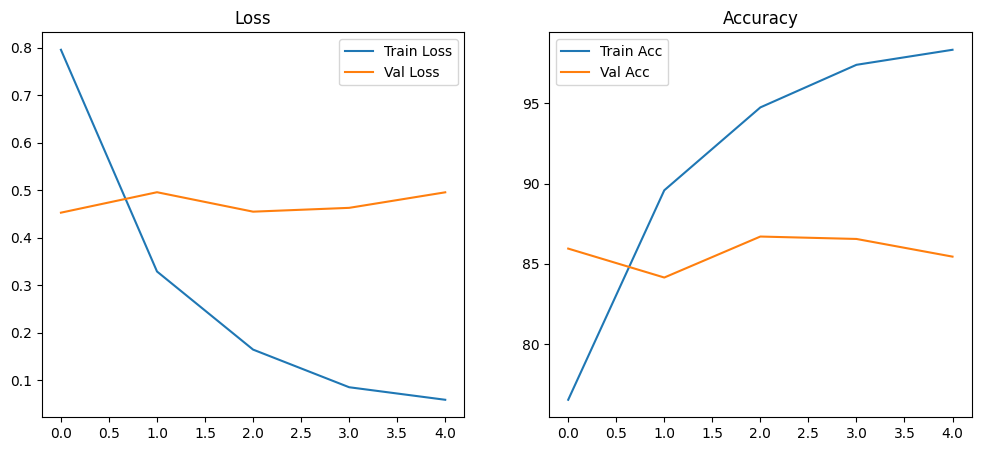

                    precision    recall  f1-score   support

    baby_back_ribs       0.80      0.95      0.87       100
           baklava       0.92      0.85      0.89       100
          bibimbap       0.97      0.89      0.93       100
        bruschetta       0.86      0.89      0.88       100
      caesar_salad       0.95      0.88      0.91       100
        cheesecake       0.81      0.87      0.84       100
     chicken_curry       0.73      0.90      0.81       100
chicken_quesadilla       0.88      0.84      0.86       100
        crab_cakes       0.73      0.86      0.79       100
         cup_cakes       0.93      0.88      0.90       100
      filet_mignon       0.64      0.66      0.65       100
    fried_calamari       0.83      0.96      0.89       100
          pancakes       0.87      0.90      0.88       100
               pho       0.95      0.94      0.94       100
   red_velvet_cake       0.92      0.89      0.90       100
            samosa       0.93      0.71

In [ ]:
# Load Model
weights = M.ResNet50_Weights.IMAGENET1K_V2
model = M.resnet50(weights=weights)

# Freeze Layers
model = unfreeze_by_name(model, keywords=["fc", "layer4"]) # fc, layer4, layer3

# Add Transforms
dataset_train.transform = weights.transforms()
dataset_eval.transform  = weights.transforms()

# DataLoader
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Modify the Model
model.fc = nn.Linear(in_features=2048, out_features=len(class_names), bias=True)

# Define Loss Function and Optimizer
loss_fn = nn.CrossEntropyLoss()
trainable_params = [p for p in model.parameters() if p.requires_grad] # Collect only trainable params
optimizer = torch.optim.Adam(trainable_params, lr=1e-3)

print(f"Trainable Params: {[n for n, p in model.named_parameters() if p.requires_grad]}")

# Create a writer with all default settings
writer = SummaryWriter()

# Train the Model
if torch.cuda.is_available():
    train_model_amp(model=model,
                loss_fn=loss_fn,
                optimizer=optimizer,
                train_dataloader=train_dataloader,
                test_dataloader=val_dataloader,
                class_names=class_names,
                device=DEVICE,
                seed=RANDOM_SEED,
                scheduler=None,
                epochs=5,
                writer=writer
                )
else:
      train_model(model=model,
                loss_fn=loss_fn,
                optimizer=optimizer,
                train_dataloader=train_dataloader,
                test_dataloader=val_dataloader,
                class_names=class_names,
                device=DEVICE,
                seed=RANDOM_SEED,
                scheduler=None,
                epochs=5,
                writer=writer
                )

### 3.2. Model 1

`efficientnet_v2_s`

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 94.3MB/s]


Trainable Params: ['features.6.0.block.0.0.weight', 'features.6.0.block.0.1.weight', 'features.6.0.block.0.1.bias', 'features.6.0.block.1.0.weight', 'features.6.0.block.1.1.weight', 'features.6.0.block.1.1.bias', 'features.6.0.block.2.fc1.weight', 'features.6.0.block.2.fc1.bias', 'features.6.0.block.2.fc2.weight', 'features.6.0.block.2.fc2.bias', 'features.6.0.block.3.0.weight', 'features.6.0.block.3.1.weight', 'features.6.0.block.3.1.bias', 'features.6.1.block.0.0.weight', 'features.6.1.block.0.1.weight', 'features.6.1.block.0.1.bias', 'features.6.1.block.1.0.weight', 'features.6.1.block.1.1.weight', 'features.6.1.block.1.1.bias', 'features.6.1.block.2.fc1.weight', 'features.6.1.block.2.fc1.bias', 'features.6.1.block.2.fc2.weight', 'features.6.1.block.2.fc2.bias', 'features.6.1.block.3.0.weight', 'features.6.1.block.3.1.weight', 'features.6.1.block.3.1.bias', 'features.6.2.block.0.0.weight', 'features.6.2.block.0.1.weight', 'features.6.2.block.0.1.bias', 'features.6.2.block.1.0.weight

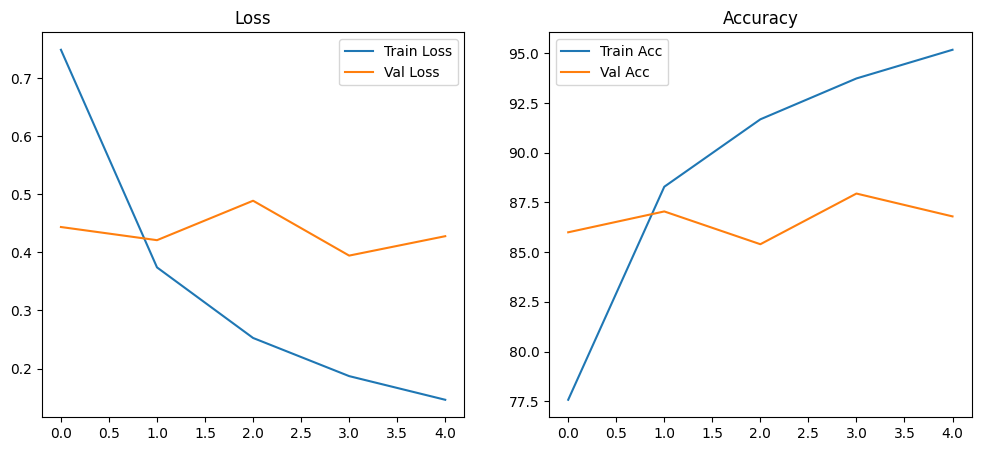

                    precision    recall  f1-score   support

    baby_back_ribs       0.74      0.92      0.82       100
           baklava       0.98      0.90      0.94       100
          bibimbap       0.85      0.96      0.90       100
        bruschetta       0.85      0.93      0.89       100
      caesar_salad       0.98      0.84      0.90       100
        cheesecake       0.92      0.89      0.90       100
     chicken_curry       0.71      0.93      0.81       100
chicken_quesadilla       0.90      0.89      0.89       100
        crab_cakes       0.86      0.84      0.85       100
         cup_cakes       0.88      0.92      0.90       100
      filet_mignon       0.78      0.59      0.67       100
    fried_calamari       0.80      1.00      0.89       100
          pancakes       0.98      0.86      0.91       100
               pho       0.95      0.97      0.96       100
   red_velvet_cake       0.91      0.90      0.90       100
            samosa       0.91      0.89

In [ ]:
# Load Model
weights = M.EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = M.efficientnet_v2_s(weights=weights)

# Freeze Layers
model = unfreeze_by_name(model, keywords=["classifier", "features.7", "features.6"]) # classifier, features.7, features.6, features.5

# Add Transforms
dataset_train.transform = weights.transforms()
dataset_eval.transform  = weights.transforms()

# DataLoader
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.mps.manual_seed(RANDOM_SEED)
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Modify the Model
model.classifier = nn.Sequential(
  nn.Dropout(p=0.2, inplace=True),
  nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
)
# model.classifier[1].out_features = len(class_names)

# Define Loss Function and Optimizer
loss_fn = nn.CrossEntropyLoss()
trainable_params = [p for p in model.parameters() if p.requires_grad] # Collect only trainable params
optimizer = torch.optim.Adam(trainable_params, lr=1e-3)

print(f"Trainable Params: {[n for n, p in model.named_parameters() if p.requires_grad]}")

# Create a writer with all default settings
writer = SummaryWriter()

# Train the Model
if torch.cuda.is_available():
    train_model_amp(model=model,
                loss_fn=loss_fn,
                optimizer=optimizer,
                train_dataloader=train_dataloader,
                test_dataloader=val_dataloader,
                class_names=class_names,
                device=DEVICE,
                seed=RANDOM_SEED,
                scheduler=None,
                epochs=5,
                writer=writer
                )
else:
      train_model(model=model,
                loss_fn=loss_fn,
                optimizer=optimizer,
                train_dataloader=train_dataloader,
                test_dataloader=val_dataloader,
                class_names=class_names,
                device=DEVICE,
                seed=RANDOM_SEED,
                scheduler=None,
                epochs=5,
                writer=writer
                )

### 3.3. Model 2

`efficientnet_b6`

In [ ]:
# import gc
# gc.collect()
# torch.cuda.empty_cache()

In [ ]:
# # Load Model
# weights = M.EfficientNet_B6_Weights.IMAGENET1K_V1
# model = M.efficientnet_b6(weights=weights)

# # Freeze Layers
# model = unfreeze_by_name(model, keywords=["classifier", "features.8"]) # classifier, features.8, features.7

# # Add Transforms
# dataset_train.transform = weights.transforms()
# dataset_eval.transform  = weights.transforms()

# # DataLoader
# torch.manual_seed(RANDOM_SEED)
# torch.cuda.manual_seed(RANDOM_SEED)
# torch.mps.manual_seed(RANDOM_SEED)
# NUM_WORKERS = os.cpu_count()

# train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
# val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
# test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# # Modify the Model
# model.classifier = nn.Sequential(
#   nn.Dropout(p=0.5, inplace=True),
#   nn.Linear(in_features=2304, out_features=len(class_names), bias=True)
# )
# # model.classifier[1].out_features = len(class_names)

# # Define Loss Function and Optimizer
# loss_fn = nn.CrossEntropyLoss()
# trainable_params = [p for p in model.parameters() if p.requires_grad] # Collect only trainable params
# optimizer = torch.optim.Adam(trainable_params, lr=1e-3)

# print(f"Trainable Params: {[n for n, p in model.named_parameters() if p.requires_grad]}")

# # Create a writer with all default settings
# writer = SummaryWriter()

# # Train the Model
# if torch.cuda.is_available():
#     train_model_amp(model=model,
#                 loss_fn=loss_fn,
#                 optimizer=optimizer,
#                 train_dataloader=train_dataloader,
#                 test_dataloader=val_dataloader,
#                 class_names=class_names,
#                 device=DEVICE,
#                 seed=RANDOM_SEED,
#                 scheduler=None,
#                 epochs=5,
#                 writer=writer
#                 )
# else:
#       train_model(model=model,
#                 loss_fn=loss_fn,
#                 optimizer=optimizer,
#                 train_dataloader=train_dataloader,
#                 test_dataloader=val_dataloader,
#                 class_names=class_names,
#                 device=DEVICE,
#                 seed=RANDOM_SEED,
#                 scheduler=None,
#                 epochs=5,
#                 writer=writer
#                 )

## **4. EfficientNet_V2_S Model**

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

def unfreeze_by_name(model, keywords=["fc", "classifier", "layer4", "features.7"]):
    for name, param in model.named_parameters():
        if any(k in name for k in keywords):
            param.requires_grad = True
        else:
            param.requires_grad = False

    return model

def seed_worker(worker_id):
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)

In [ ]:
# Load Model
weights = M.EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = M.efficientnet_v2_s(weights=weights)

# Freeze Layers
model = unfreeze_by_name(model, keywords=["classifier", "features.7", "features.6"]) # classifier, features.7, features.6, features.5

# Modify the Model
model.classifier = nn.Sequential(
  nn.Dropout(p=0.3, inplace=True),
  nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
)

# ### Non Linear 1
# model.classifier = nn.Sequential(
#     nn.Linear(1280, 512),
#     nn.BatchNorm1d(512),
#     nn.ReLU(inplace=True),
#     nn.Dropout(0.3),
#     nn.Linear(512, 256),
#     nn.BatchNorm1d(256),
#     nn.ReLU(inplace=True),
#     nn.Dropout(0.2),
#     nn.Linear(256, len(class_names))
# )

# ### Non Linear 2
# model.classifier = nn.Sequential(
#     nn.Linear(1280, 512),
#     nn.GELU(),
#     nn.Dropout(0.3),
#     nn.Linear(512, 256),
#     nn.BatchNorm1d(256),
#     nn.GELU(),
#     nn.Dropout(0.2),
#     nn.Linear(256, len(class_names))
# )

In [ ]:
# ### Type 1
# train_transform = T.Compose([
#     T.Resize(384, interpolation=T.InterpolationMode.BILINEAR),
#     T.CenterCrop(384),
#     T.RandomHorizontalFlip(p=0.5),
#     T.RandomVerticalFlip(p=0.1),
#     T.RandomRotation((0, 20)),
#     T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Lighting/food variety
#     T.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Slight translations
#     T.ToTensor(),
#     T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
# ])

### Type 2
train_transform = T.Compose([
    T.RandomResizedCrop(384, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(0.2, 0.2, 0.2, 0.1),
    T.RandomAffine(degrees=20, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    T.RandomErasing(p=0.3)
])

eval_transform = T.Compose([
    T.Resize(384, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(384),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])


# ### Type 3
# train_transform = T.Compose([
#     T.RandomResizedCrop(256, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
#     T.RandomHorizontalFlip(p=0.5),
#     T.ColorJitter(0.2, 0.2, 0.2, 0.1),
#     T.RandomAffine(degrees=20, translate=(0.1, 0.1)),
#     T.ToTensor(),
#     T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
#     T.RandomErasing(p=0.3)
# ])

# eval_transform = T.Compose([
#     T.Resize(256, interpolation=T.InterpolationMode.BILINEAR),
#     T.CenterCrop(256),
#     T.ToTensor(),
#     T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
# ])

In [ ]:
# Add Transforms
dataset_train.transform = train_transform
dataset_eval.transform  = eval_transform

# Set Seed
set_seed(RANDOM_SEED)

# DataLoader
NUM_WORKERS = os.cpu_count()
g = torch.Generator()
g.manual_seed(RANDOM_SEED)

train_dataloader = DataLoader(train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              num_workers=NUM_WORKERS,
                              pin_memory=True,
                              worker_init_fn=seed_worker,
                              generator=g)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

In [ ]:
# Define Loss Function and Optimizer
loss_fn = nn.CrossEntropyLoss()

trainable_params = [p for p in model.parameters() if p.requires_grad] # Collect only trainable params
optimizer = torch.optim.Adam(trainable_params, lr=1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

Trainable Params: ['features.6.0.block.0.0.weight', 'features.6.0.block.0.1.weight', 'features.6.0.block.0.1.bias', 'features.6.0.block.1.0.weight', 'features.6.0.block.1.1.weight', 'features.6.0.block.1.1.bias', 'features.6.0.block.2.fc1.weight', 'features.6.0.block.2.fc1.bias', 'features.6.0.block.2.fc2.weight', 'features.6.0.block.2.fc2.bias', 'features.6.0.block.3.0.weight', 'features.6.0.block.3.1.weight', 'features.6.0.block.3.1.bias', 'features.6.1.block.0.0.weight', 'features.6.1.block.0.1.weight', 'features.6.1.block.0.1.bias', 'features.6.1.block.1.0.weight', 'features.6.1.block.1.1.weight', 'features.6.1.block.1.1.bias', 'features.6.1.block.2.fc1.weight', 'features.6.1.block.2.fc1.bias', 'features.6.1.block.2.fc2.weight', 'features.6.1.block.2.fc2.bias', 'features.6.1.block.3.0.weight', 'features.6.1.block.3.1.weight', 'features.6.1.block.3.1.bias', 'features.6.2.block.0.0.weight', 'features.6.2.block.0.1.weight', 'features.6.2.block.0.1.bias', 'features.6.2.block.1.0.weight

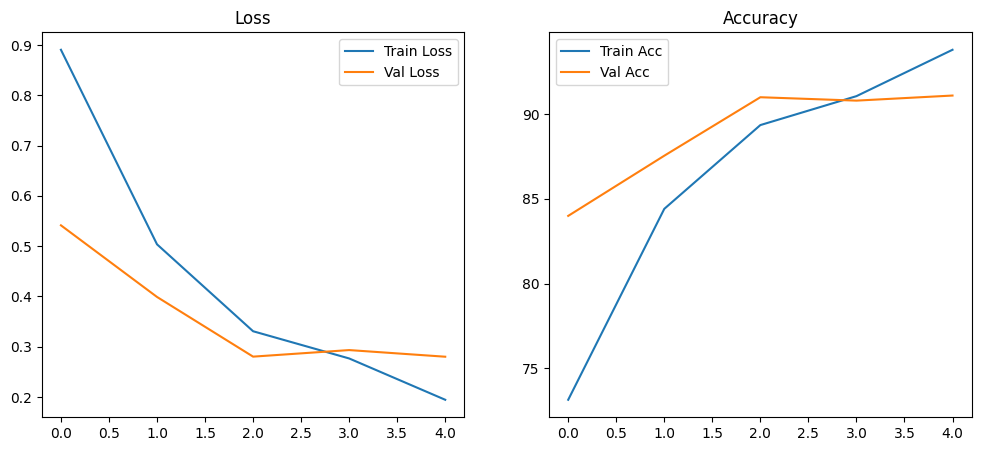

                    precision    recall  f1-score   support

    baby_back_ribs       0.98      0.84      0.90       100
           baklava       0.96      0.97      0.97       100
          bibimbap       0.98      0.97      0.97       100
        bruschetta       0.94      0.85      0.89       100
      caesar_salad       0.93      0.96      0.95       100
        cheesecake       0.95      0.82      0.88       100
     chicken_curry       0.97      0.92      0.94       100
chicken_quesadilla       0.87      0.97      0.92       100
        crab_cakes       0.84      0.94      0.89       100
         cup_cakes       0.95      0.97      0.96       100
      filet_mignon       0.73      0.76      0.75       100
    fried_calamari       0.97      0.96      0.96       100
          pancakes       0.86      0.96      0.91       100
               pho       0.95      0.97      0.96       100
   red_velvet_cake       0.92      0.94      0.93       100
            samosa       0.90      0.91

In [ ]:
print(f"Trainable Params: {[n for n, p in model.named_parameters() if p.requires_grad]}")

# Create a writer with all default settings
writer = SummaryWriter()

# Train the Model
if torch.cuda.is_available():
    # With Automatic Mixed Precision
    train_model_amp(model=model,
                loss_fn=loss_fn,
                optimizer=optimizer,
                train_dataloader=train_dataloader,
                test_dataloader=val_dataloader,
                class_names=class_names,
                device=DEVICE,
                seed=RANDOM_SEED,
                scheduler=scheduler,
                epochs=5,
                writer=writer
                )
else:
    train_model(model=model,
              loss_fn=loss_fn,
              optimizer=optimizer,
              train_dataloader=train_dataloader,
              test_dataloader=val_dataloader,
              class_names=class_names,
              device=DEVICE,
              seed=RANDOM_SEED,
              scheduler=scheduler,
              epochs=5,
              writer=writer
              )

Using Automatic Mixed Precision (AMP) in PyTorch (or TensorFlow) does not fundamentally change the behavior of your model, but it can introduce small numerical differences.

## **5. Save Model**

In [ ]:
cnn_model_dict = {
    "model_state_dict": model.to("cpu").state_dict(), # Can't deserialize cuda with cpu on loading
    "num_classes": len(class_names),
    "batch_size": train_dataloader.batch_size,
    "img_shape": next(iter(train_dataloader))[0][0].shape,
    "loss_fn":str(loss_fn),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "architecture": str(model),
    "train_transfrom":  str(train_transform.transforms),
    "test_transfrom":  str(eval_transform.transforms),
    "require_grad_layers": trainable_params,
    "classifier": model.classifier
}

model = model.to(DEVICE) # Put back model to current device

In [ ]:
torch.save(cnn_model_dict, OUTPATH)

Save on Google Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# torch.save(cnn_model_dict, f"/content/drive/MyDrive/{OUTPATH}")

## **6. Load Model & Eval**

In [ ]:
# Download the pretrained model
import gdown

if P == 20:
  link = "https://drive.google.com/file/d/1__3UBxj8aODGSr_GyO5IzNb9xxydG7ao/view?usp=sharing" # 20%
else:
  link = "https://drive.google.com/file/d/1LJ27dH-V4pdK5640MrLLSN9DAlOwDf5C/view?usp=sharing" # 100%

file_id = link.split("/")[-2]

gdown.download(f'https://drive.google.com/uc?id={file_id}', OUTPATH, quiet=True)

'pytorch_0008_efficientnet_v2_s_20p.pth'

In [ ]:
cnn_model_dict_l = torch.load(OUTPATH, weights_only=False, map_location=torch.device(DEVICE))
cnn_model_dict_l.keys()

dict_keys(['model_state_dict', 'num_classes', 'batch_size', 'img_shape', 'loss_fn', 'optimizer', 'scheduler', 'architecture', 'train_transfrom', 'test_transfrom', 'require_grad_layers', 'classifier'])

In [ ]:
# Load pretrained EfficientNet_V2_S
weights_temp = M.EfficientNet_V2_S_Weights.IMAGENET1K_V1
model_temp = M.efficientnet_v2_s(weights=weights_temp)

for param in model_temp.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 142MB/s]


In [ ]:
model_temp.classifier = cnn_model_dict_l["classifier"]

In [ ]:
model_temp.load_state_dict(cnn_model_dict_l["model_state_dict"])

<All keys matched successfully>

In [ ]:
model_temp = model_temp.to(DEVICE)

In [ ]:
next(model_temp.parameters()).device

device(type='cuda', index=0)

### 6.0. Eval Loaded Model

In [ ]:
cnn_model_dict_l["test_transfrom"]

'[Resize(size=384, interpolation=bilinear, max_size=None, antialias=True), CenterCrop(size=(384, 384)), ToTensor(), Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))]'

In [ ]:
# Add Transforms
dataset_eval.transform  = T.Compose([
    T.Resize(384, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(384),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

val_dataloader_temp = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dataloader_temp = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Val

In [ ]:
probs, preds, targets = eval_model(model=model_temp, dataloader=val_dataloader_temp, device=DEVICE)
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

                    precision    recall  f1-score   support

    baby_back_ribs       0.93      0.90      0.91       100
           baklava       0.92      0.96      0.94       100
          bibimbap       0.96      0.99      0.98       100
        bruschetta       0.93      0.85      0.89       100
      caesar_salad       0.94      0.95      0.95       100
        cheesecake       0.93      0.87      0.90       100
     chicken_curry       0.96      0.93      0.94       100
chicken_quesadilla       0.91      0.95      0.93       100
        crab_cakes       0.84      0.98      0.90       100
         cup_cakes       0.93      0.99      0.96       100
      filet_mignon       0.73      0.76      0.75       100
    fried_calamari       0.99      0.97      0.98       100
          pancakes       0.93      0.91      0.92       100
               pho       0.99      0.96      0.97       100
   red_velvet_cake       0.93      0.93      0.93       100
            samosa       0.92      0.89

Test

In [ ]:
probs, preds, targets = eval_model(model=model_temp, dataloader=test_dataloader_temp, device=DEVICE)
print(classification_report(y_pred=preds.numpy(), y_true=targets.numpy(), target_names=class_names))

                    precision    recall  f1-score   support

    baby_back_ribs       0.92      0.88      0.90       200
           baklava       0.96      0.94      0.95       200
          bibimbap       0.96      0.96      0.96       200
        bruschetta       0.94      0.90      0.92       200
      caesar_salad       0.93      0.98      0.96       200
        cheesecake       0.93      0.91      0.92       200
     chicken_curry       0.94      0.88      0.91       200
chicken_quesadilla       0.90      0.97      0.93       200
        crab_cakes       0.87      0.94      0.90       200
         cup_cakes       0.90      0.95      0.92       200
      filet_mignon       0.71      0.82      0.76       200
    fried_calamari       0.98      0.93      0.95       200
          pancakes       0.96      0.89      0.92       200
               pho       0.98      0.96      0.97       200
   red_velvet_cake       0.90      0.91      0.90       200
            samosa       0.94      0.88

## **7. TensorBoard**

In [ ]:
import shutil

# shutil.make_archive("model_logs", 'zip', "runs")

In [ ]:
import requests

result = requests.get("https://github.com/RezaTaheri01/my-ml-journey/raw/refs/heads/main/Codes/pytorch/models/pytorch_0008/model_logs.zip")

with open("runs.zip", "wb") as file:
  file.write(result.content)

shutil.unpack_archive("runs.zip", "runs", "zip")

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs